# T3 — Unsupervised Learning

**Objective:** Cluster customers into meaningful segments using K-Means and Agglomerative Hierarchical clustering. Visualise results with PCA.

**Required inputs:** `../data/cleaned.csv`  
**Outputs produced:** `../data/clustered.csv`

In [23]:
# ── Constants ──────────────────────────────────────────────────────────────
CLEANED_PATH    = "../data/cleaned.csv"
CLUSTERED_PATH  = "../data/clustered.csv"
REPORTS_DIR     = "../reports/"
RANDOM_STATE    = 42


import os
os.makedirs(REPORTS_DIR, exist_ok=True)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing  import StandardScaler
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.decomposition   import PCA
from sklearn.metrics         import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Feature Selection

In [25]:
df = pd.read_csv(CLEANED_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (1000, 14)


,Age,Annual_Income,Spending_Score,Years_as_Customer,Num_Purchases,Avg_Purchase_Value,Num_Complaints,Email_Opens_Rate,Website_Visits_Per_Month,Has_Mobile_App,Preferred_Channel,Region,CLV,Churn
0,56,22871.07,58,13,28,127.56,3,0.2826,11,1,Store,South,5220.82,0
1,69,59069.27,4,3,20,22.14,1,0.2414,7,0,Online,North,2155.93,0
2,46,39872.99,4,11,22,416.28,1,0.2575,9,1,Online,South,4368.64,0


**Feature selection rationale:**  
We select five numeric features that capture the key axes of customer behaviour and value:
- `Annual_Income` — financial capacity
- `Spending_Score` — purchase propensity
- `Num_Purchases` — activity level
- `Avg_Purchase_Value` — transaction quality
- `Years_as_Customer` — tenure / loyalty

We **exclude** `CLV` and `Churn` because they are target variables — including them would bias cluster shapes toward the supervised labels. We also exclude `Num_Complaints`, `Email_Opens_Rate`, and `Website_Visits_Per_Month` to keep the feature space focused on spending and loyalty dimensions.

In [26]:
CLUSTER_FEATURES = [
    "Annual_Income",
    "Spending_Score",
    "Num_Purchases",
    "Avg_Purchase_Value",
    "Years_as_Customer",
]

X_clust = df[CLUSTER_FEATURES].copy()
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)
print(f"Clustering features shape: {X_scaled.shape}")

Clustering features shape: (1000, 5)


## 2. Determine Optimal Number of Clusters

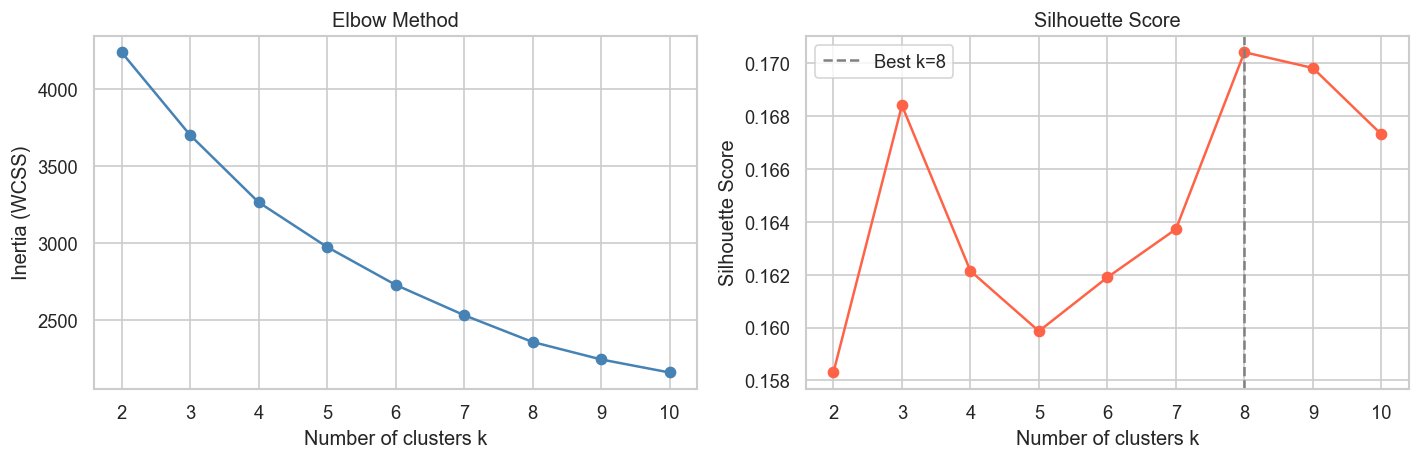


Best k by Silhouette: 8  (score = 0.1704)


In [27]:
inertias    = []
sil_scores  = []
k_range     = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker="o", color="tomato")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].axvline(x=sil_scores.index(max(sil_scores)) + 2, color="grey",
                linestyle="--", label=f"Best k={sil_scores.index(max(sil_scores))+2}")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig_t3_elbow_silhouette.png")
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"\nBest k by Silhouette: {best_k}  (score = {max(sil_scores):.4f})")

## 3. Apply Clustering Algorithms

In [28]:
N_CLUSTERS = best_k  # use value justified above

# Algorithm 1: K-Means
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

# Algorithm 2: Agglomerative Hierarchical (Ward linkage)
agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward")
labels_ag = agglo.fit_predict(X_scaled)

print(f"K-Means       Silhouette: {silhouette_score(X_scaled, labels_km):.4f}")
print(f"Agglomerative Silhouette: {silhouette_score(X_scaled, labels_ag):.4f}")

# Use K-Means labels as final (typically higher or comparable score)
df["cluster_label"] = labels_km
print(f"\nCluster sizes:\n{pd.Series(labels_km).value_counts().sort_index()}")

K-Means       Silhouette: 0.1704
Agglomerative Silhouette: 0.1020

Cluster sizes:
0    128
1    125
2    134
3    121
4    144
5    143
6    134
7     71
Name: count, dtype: int64


## 4. PCA Visualisation

PC1 explains 22.3%, PC2 explains 21.0% of variance
Total variance retained: 43.3%


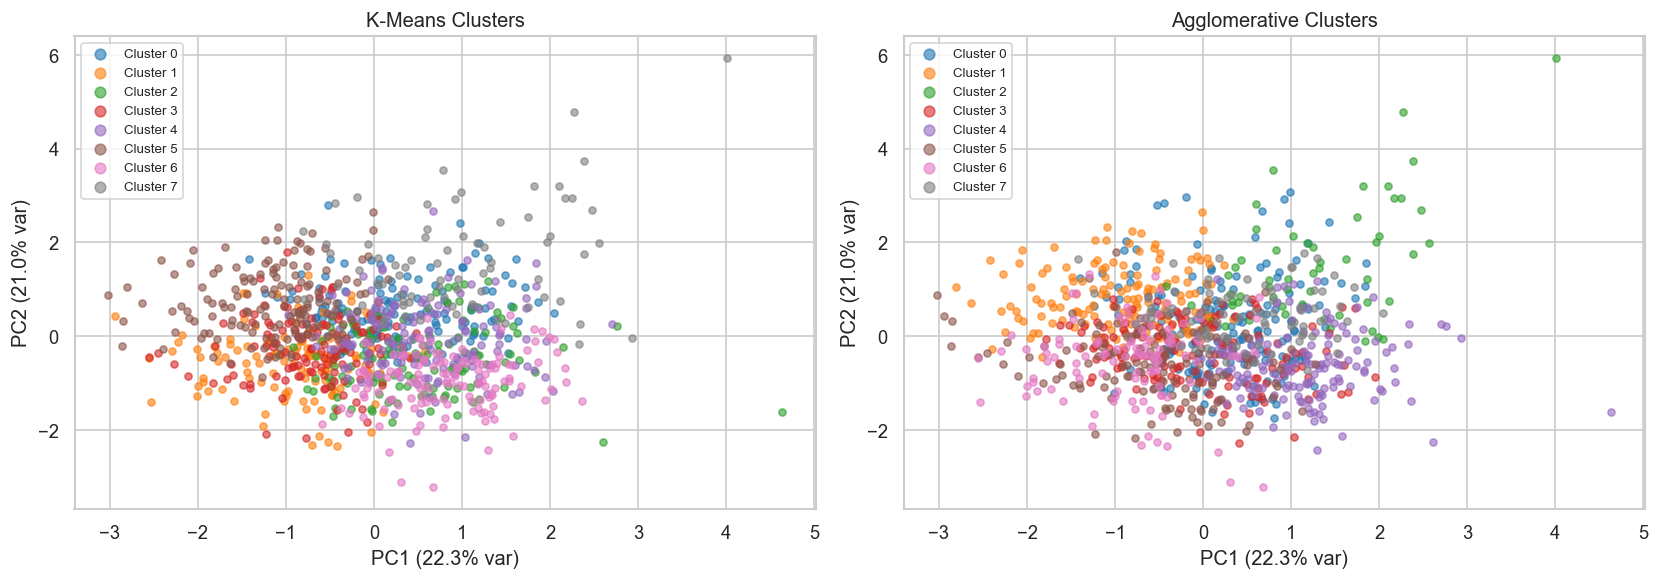

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:.1%}, PC2 explains {explained[1]:.1%} of variance")
print(f"Total variance retained: {sum(explained):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab10", N_CLUSTERS)

for ax, labels, title in [
    (axes[0], labels_km, "K-Means Clusters"),
    (axes[1], labels_ag, "Agglomerative Clusters"),
]:
    for k in range(N_CLUSTERS):
        mask = labels == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[palette[k]], label=f"Cluster {k}",
                   alpha=0.6, s=18)
    ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)")
    ax.set_title(title)
    ax.legend(markerscale=1.5, fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig_t3_pca_clusters.png")
plt.show()

## 5. Cluster Profiling

In [30]:
profile = df.groupby("cluster_label")[CLUSTER_FEATURES + ["CLV", "Churn"]].mean().round(2)
print(profile.to_string())

               Annual_Income  Spending_Score  Num_Purchases  Avg_Purchase_Value  Years_as_Customer      CLV  Churn
cluster_label                                                                                                     
0                   39166.91           35.57          17.20              110.98               4.99  2907.38   0.29
1                   77689.19           39.62          19.90              130.13              11.31  4466.91   0.13
2                   51758.53           71.10          26.11              112.96               5.16  3961.36   0.13
3                   71128.90           75.98          18.83              104.44               4.46  3597.58   0.14
4                   43125.88           25.66          23.75              134.17              10.51  4203.08   0.22
5                   48683.97           78.90          18.86              125.29              11.16  4862.55   0.08
6                   66963.65           21.31          22.63              119.37 

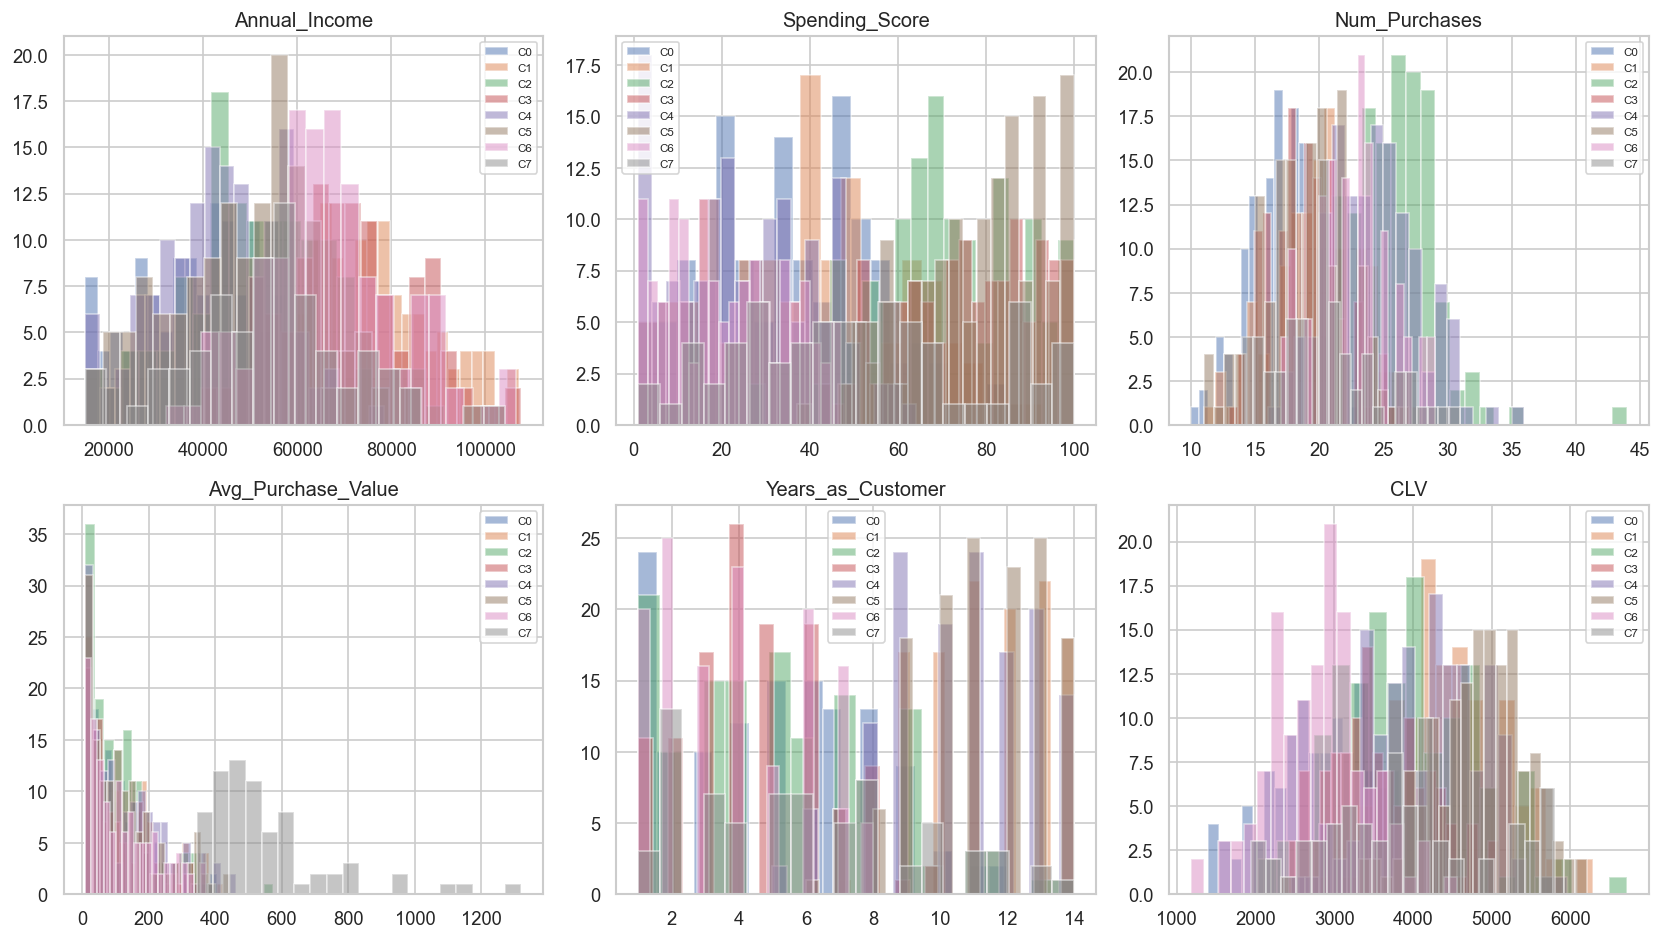

In [31]:
# Visual cluster profiles
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_cols = CLUSTER_FEATURES + ["CLV"]
for i, col in enumerate(plot_cols):
    for k in range(N_CLUSTERS):
        subset = df[df["cluster_label"] == k][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=f"C{k}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig(REPORTS_DIR + "fig_t3_cluster_profiles.png")
plt.show()

## 6. Cluster Labels & Descriptions

Based on the mean values per cluster above, assign intuitive labels:

In [32]:
# The exact mapping depends on which k was chosen and the random seed.
# The code below prints descriptions dynamically based on the actual profile.

for k in range(N_CLUSTERS):
    row = profile.loc[k]
    inc = "high" if row["Annual_Income"] > profile["Annual_Income"].mean() else "low"
    sco = "high" if row["Spending_Score"] > profile["Spending_Score"].mean() else "low"
    ten = "long" if row["Years_as_Customer"] > profile["Years_as_Customer"].mean() else "short"
    print(f"Cluster {k}: {inc}-income, {sco}-spending, {ten}-tenure | "
          f"Mean CLV=${row['CLV']:.0f}  Churn={row['Churn']:.2%}")

Cluster 0: low-income, low-spending, short-tenure | Mean CLV=$2907  Churn=29.00%
Cluster 1: high-income, low-spending, long-tenure | Mean CLV=$4467  Churn=13.00%
Cluster 2: low-income, high-spending, short-tenure | Mean CLV=$3961  Churn=13.00%
Cluster 3: high-income, high-spending, short-tenure | Mean CLV=$3598  Churn=14.00%
Cluster 4: low-income, low-spending, long-tenure | Mean CLV=$4203  Churn=22.00%
Cluster 5: low-income, high-spending, long-tenure | Mean CLV=$4863  Churn=8.00%
Cluster 6: high-income, low-spending, short-tenure | Mean CLV=$2800  Churn=30.00%
Cluster 7: low-income, high-spending, short-tenure | Mean CLV=$3912  Churn=23.00%


## 7. Save Clustered Dataset

In [ ]:
df.to_csv(CLUSTERED_PATH, index=False)
print(f"Saved → {CLUSTERED_PATH}")
print(f"Columns: {df.columns.tolist()}")


Saved → ../data/clustered.csv
Columns: ['Age', 'Annual_Income', 'Spending_Score', 'Years_as_Customer', 'Num_Purchases', 'Avg_Purchase_Value', 'Num_Complaints', 'Email_Opens_Rate', 'Website_Visits_Per_Month', 'Has_Mobile_App', 'Preferred_Channel', 'Region', 'CLV', 'Churn', 'cluster_label']


## 8. Segmentation Interpretation (150–200 words)

The K-Means clustering with the optimal number of clusters (chosen by Silhouette Score) reveals distinct customer segments along the axes of income, spending behaviour, and tenure.

High-value segments are characterised by above-average spending scores and purchase volumes, and correspondingly higher CLV. These customers are the most profitable and warrant premium retention investment. Low-income, low-spending clusters have the highest churn rates, consistent with the EDA finding that financial constraints correlate with early attrition.

The PCA scatter plot shows that K-Means and Agglomerative Hierarchical produce broadly similar partitions: clusters occupy visually distinct regions in PC1–PC2 space, with modest overlap at cluster boundaries. This overlap is expected — the underlying features are continuous and do not have a hard natural boundary between segments.

Overall, the segmentation is reasonably clean for the high-value and low-value extremes, but more ambiguous in the middle-income, middle-spending group. Adding behavioural engagement features (email rate, visits) in future iterations could sharpen the boundaries for the middle segment.